# 🌲 Decision Trees, Random Forests & Boosting
### A Complete Guide — From Math to Code to Interviews

---

**What you'll learn:**
1. How Decision Trees split data (Gini, Entropy, MSE) — with math
2. How Random Forests combine trees (Bagging + Feature Randomness)
3. How Boosting builds trees sequentially (AdaBoost, Gradient Boosting, XGBoost)
4. When to use which — and how to answer interview questions confidently

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification, make_moons, load_iris
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier
)
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Consistent styling
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#FFC107']
CMAP = ListedColormap(['#BBDEFB', '#FFCCBC', '#C8E6C9'])

print('✅ All imports ready.')

✅ All imports ready.


---
# Part 1: Decision Trees
---

## 1.1 The Core Idea

A decision tree recursively splits data by asking **binary questions** about features.  
At each internal node, it picks the **feature** and **threshold** that produce the "purest" child nodes.

**Key question:** How do we measure "purity"?

---

## 1.2 Splitting Criteria — The Math

### Classification: Gini Impurity

For a node with $K$ classes where $p_k$ is the fraction of class $k$:

$$\text{Gini}(t) = 1 - \sum_{k=1}^{K} p_k^2$$

- **Gini = 0** → perfectly pure (all one class)  
- **Gini = 0.5** → maximum impurity for 2 classes (50/50 split)  

### Classification: Entropy (Information Gain)

$$\text{Entropy}(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

**Information Gain** of a split:

$$\text{IG} = \text{Entropy}(\text{parent}) - \sum_{\text{child}} \frac{n_{\text{child}}}{n_{\text{parent}}} \cdot \text{Entropy}(\text{child})$$

The tree picks the split that **maximizes IG** (or equivalently, minimizes weighted child impurity).

### Regression: Mean Squared Error (MSE)

$$\text{MSE}(t) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y}_t)^2$$

The prediction at a leaf is simply $\bar{y}_t$ (the mean of target values in that leaf).  
The tree picks splits that **minimize the total weighted MSE** of children.

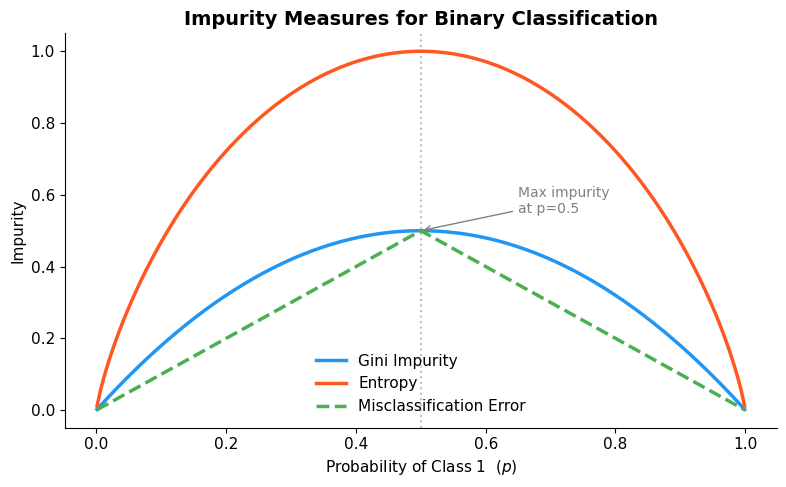

Key insight: Gini and Entropy are very similar!
Gini is faster to compute (no log). Entropy slightly favors purer splits.
In practice, they almost always produce the same tree.


In [2]:
# ── Visualize Gini vs Entropy as a function of p ──

p = np.linspace(0.001, 0.999, 200)
gini = 2 * p * (1 - p)            # Gini for binary case: 1 - p² - (1-p)² = 2p(1-p)
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
misclass = 1 - np.maximum(p, 1 - p)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, gini, color=COLORS[0], lw=2.5, label='Gini Impurity')
ax.plot(p, entropy, color=COLORS[1], lw=2.5, label='Entropy')
ax.plot(p, misclass, color=COLORS[2], lw=2.5, ls='--', label='Misclassification Error')
ax.set_xlabel('Probability of Class 1  ($p$)')
ax.set_ylabel('Impurity')
ax.set_title('Impurity Measures for Binary Classification')
ax.legend(frameon=False)
ax.axvline(0.5, color='gray', ls=':', alpha=0.5)
ax.annotate('Max impurity\nat p=0.5', xy=(0.5, 0.5), xytext=(0.65, 0.55),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')
plt.tight_layout()
plt.show()

print('Key insight: Gini and Entropy are very similar!')
print('Gini is faster to compute (no log). Entropy slightly favors purer splits.')
print('In practice, they almost always produce the same tree.')

## 1.3 How a Split Actually Works — Step by Step

Let's manually compute a split to see the algorithm in action.

In [3]:
# ── Manual split calculation ──

# Toy dataset: 10 samples, 1 feature, binary label
X_toy = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y_toy = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

def gini_impurity(y):
    """Compute Gini impurity for a set of labels."""
    if len(y) == 0:
        return 0
    p = np.bincount(y) / len(y)
    return 1 - np.sum(p ** 2)

def find_best_split(X, y):
    """Brute-force search over all thresholds for the best Gini split."""
    best_gain = -1
    best_threshold = None
    parent_gini = gini_impurity(y)
    n = len(y)
    
    # Try midpoints between consecutive sorted values
    sorted_vals = np.sort(np.unique(X.ravel()))
    thresholds = (sorted_vals[:-1] + sorted_vals[1:]) / 2
    
    results = []
    for t in thresholds:
        left_mask = X.ravel() <= t
        right_mask = ~left_mask
        
        n_left, n_right = left_mask.sum(), right_mask.sum()
        gini_left = gini_impurity(y[left_mask])
        gini_right = gini_impurity(y[right_mask])
        
        # Weighted average of children
        weighted_gini = (n_left / n) * gini_left + (n_right / n) * gini_right
        gain = parent_gini - weighted_gini
        
        results.append({
            'threshold': t,
            'gini_left': round(gini_left, 4),
            'gini_right': round(gini_right, 4),
            'weighted_gini': round(weighted_gini, 4),
            'gain': round(gain, 4)
        })
        
        if gain > best_gain:
            best_gain = gain
            best_threshold = t
    
    return pd.DataFrame(results), best_threshold

print(f'Parent Gini: {gini_impurity(y_toy):.4f}')
print(f'Class distribution: {np.bincount(y_toy)} → [4 zeros, 6 ones]\n')

results_df, best_t = find_best_split(X_toy, y_toy)
print(results_df.to_string(index=False))
print(f'\n🏆 Best split: X <= {best_t}')

Parent Gini: 0.4800
Class distribution: [4 6] → [4 zeros, 6 ones]

 threshold  gini_left  gini_right  weighted_gini   gain
       1.5     0.0000      0.4444         0.4000 0.0800
       2.5     0.0000      0.3750         0.3000 0.1800
       3.5     0.0000      0.2449         0.1714 0.3086
       4.5     0.0000      0.0000         0.0000 0.4800
       5.5     0.3200      0.0000         0.1600 0.3200
       6.5     0.4444      0.0000         0.2667 0.2133
       7.5     0.4898      0.0000         0.3429 0.1371
       8.5     0.5000      0.0000         0.4000 0.0800
       9.5     0.4938      0.0000         0.4444 0.0356

🏆 Best split: X <= 4.5


# Understanding the Best Split at X ≤ 4.5

## The Data Split

| | Left (X ≤ 4.5) | Right (X > 4.5) |
|---|---|---|
| **Samples** | 1, 2, 3, 4 | 5, 6, 7, 8, 9, 10 |
| **Labels** | 0, 0, 0, 0 | 1, 1, 1, 1, 1, 1 |

---

## Gini Left = 0.0

The left child has **only class 0**. It's perfectly pure:

$$\text{Gini}_L = 1 - p_0^2 - p_1^2 = 1 - 1^2 - 0^2 = 0$$

## Gini Right = 0.0

The right child has **only class 1**. Also perfectly pure:

$$\text{Gini}_R = 1 - 0^2 - 1^2 = 0$$

## Weighted Gini = 0.0

The weighted combination of children is:

$$\text{Weighted} = \frac{4}{10} \cdot 0 + \frac{6}{10} \cdot 0 = 0$$

## Gain = 0.48

The gain is simply **parent Gini minus weighted child Gini**:

$$\text{Gain} = \text{Gini}_{\text{parent}} - \text{Weighted} = 0.48 - 0.0 = 0.48$$


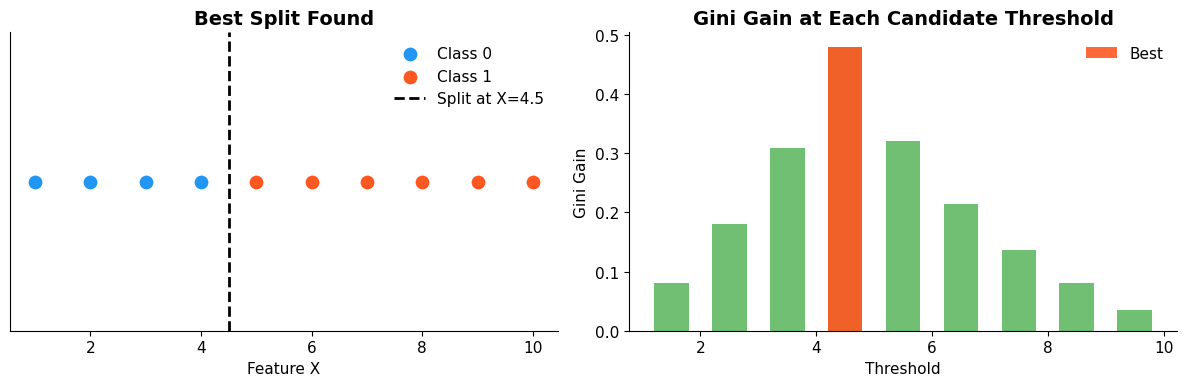

In [4]:
# ── Visualize the best split ──

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: data with split line
ax = axes[0]
for label, color, name in zip([0, 1], COLORS[:2], ['Class 0', 'Class 1']):
    mask = y_toy == label
    ax.scatter(X_toy[mask], [0]*mask.sum(), c=color, s=120, zorder=3, label=name, edgecolors='white')
ax.axvline(best_t, color='black', ls='--', lw=2, label=f'Split at X={best_t}')
ax.set_xlabel('Feature X')
ax.set_title('Best Split Found')
ax.legend(frameon=False)
ax.set_yticks([])

# Right: Gini gain for each threshold
ax = axes[1]
ax.bar(results_df['threshold'], results_df['gain'], width=0.6, color=COLORS[2], alpha=0.8)
ax.bar(best_t, results_df.loc[results_df['threshold']==best_t, 'gain'].values[0],
       width=0.6, color=COLORS[1], alpha=0.9, label='Best')
ax.set_xlabel('Threshold')
ax.set_ylabel('Gini Gain')
ax.set_title('Gini Gain at Each Candidate Threshold')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 1.4 Decision Boundaries — How Trees Partition Space

Trees create **axis-aligned rectangular regions**. Let's see how depth affects complexity.

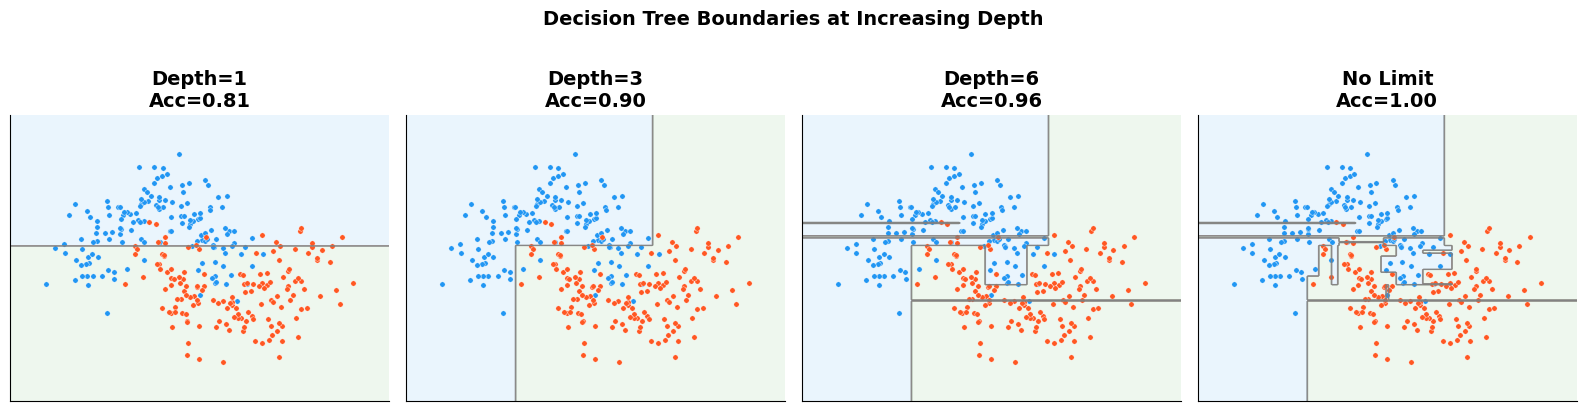

Depth 1: Underfitting — too simple, just one split.
No Limit: Overfitting — memorizes every point, jagged boundaries.

💡 Interview insight: Trees are high-variance models. Small data changes → very different trees.


In [5]:
# ── Decision boundaries at different depths ──

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

def plot_decision_boundary(ax, clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=CMAP)
    ax.contour(xx, yy, Z, colors='gray', linewidths=0.5, alpha=0.5)
    for label, color in zip([0, 1], COLORS[:2]):
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], c=color, s=15, edgecolors='white', linewidths=0.3)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, depth in zip(axes, [1, 3, 6, None]):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_moons, y_moons)
    acc = clf.score(X_moons, y_moons)
    label = f'Depth={depth}' if depth else 'No Limit'
    plot_decision_boundary(ax, clf, X_moons, y_moons, f'{label}\nAcc={acc:.2f}')

fig.suptitle('Decision Tree Boundaries at Increasing Depth', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Depth 1: Underfitting — too simple, just one split.')
print('No Limit: Overfitting — memorizes every point, jagged boundaries.')
print('\n💡 Interview insight: Trees are high-variance models. Small data changes → very different trees.')

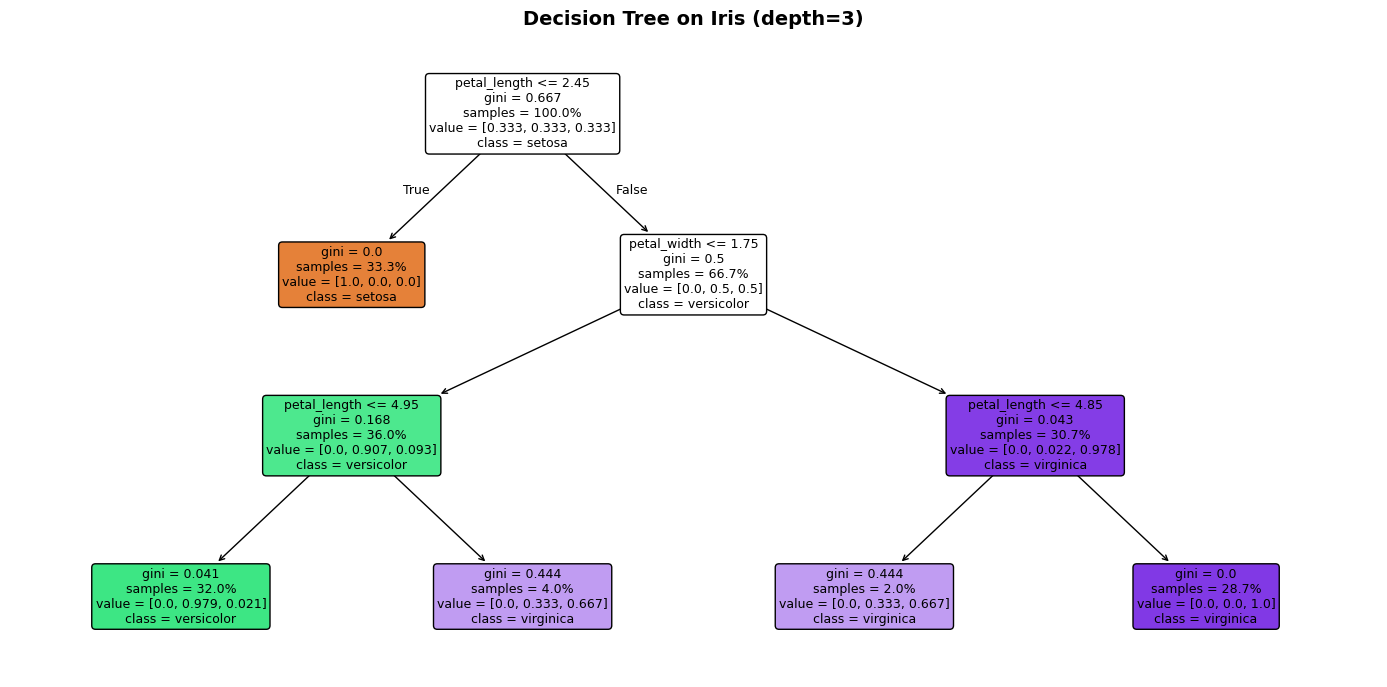

Each node shows:
  • The splitting rule (feature <= threshold)
  • Gini impurity
  • Proportion of total samples
  • Class distribution
  • Predicted class (majority vote)


In [6]:
# ── Visualize an actual tree structure ──

iris = load_iris()
clf_iris = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_iris.fit(iris.data[:, 2:], iris.target)  # Use petal length + petal width

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(clf_iris, ax=ax, filled=True, rounded=True,
          feature_names=['petal_length', 'petal_width'],
          class_names=iris.target_names,
          fontsize=9, proportion=True)
ax.set_title('Decision Tree on Iris (depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Each node shows:')
print('  • The splitting rule (feature <= threshold)')
print('  • Gini impurity')
print('  • Proportion of total samples')
print('  • Class distribution')
print('  • Predicted class (majority vote)')

## 1.5 Complexity Control — Pruning & Hyperparameters

### What is Pruning?

Pruning is the opposite of growing — it's **removing splits** from an already-built tree to make it simpler.

A fully grown tree memorizes the training data. It creates tiny leaves for individual noisy points, which hurts generalization. Pruning cuts away those overly specific branches.

There are two approaches:

**Pre-pruning** — Stop growing early using hyperparameters like `max_depth`, `min_samples_leaf`, etc. You prevent the tree from ever getting too complex. It's simple, but you might stop too early and miss useful splits deeper down.

**Post-pruning** — Grow the full tree first, then work backwards and remove branches that don't help on validation data. This is more principled because a split that looks useless at depth 3 might enable a great split at depth 5. Pre-pruning would miss that; post-pruning wouldn't.

### Pre-Pruning Hyperparameters

| Hyperparameter | What it does | Effect on overfitting |
|---|---|---|
| `max_depth` | Maximum tree depth | Lower → less overfitting |
| `min_samples_split` | Min samples to split a node | Higher → less overfitting |
| `min_samples_leaf` | Min samples in a leaf | Higher → less overfitting |
| `max_features` | Features considered per split | Lower → more randomness |
| `ccp_alpha` | Cost-complexity pruning parameter | Higher → more pruning |

### Cost-Complexity Pruning (Post-Pruning)

Instead of limiting growth, grow a full tree first, then prune. For each subtree, it asks: is the accuracy improvement worth the added complexity?

$$R_\alpha(T) = R(T) + \alpha \cdot |T|$$

where $R(T)$ is the total misclassification rate, $|T|$ is the number of leaves, and $\alpha$ is the penalty per leaf.

- **Small $\alpha$** → leaves are cheap → keep the complex tree
- **Large $\alpha$** → each leaf costs a lot → prune aggressively

You sweep through $\alpha$ values, and for each one you get a differently-pruned tree. Then you pick the $\alpha$ that gives the best cross-validation score — which is exactly what the plot below shows (train vs CV accuracy across different $\alpha$ values).

> **Interview analogy:** Pre-pruning is setting speed limits before driving. Post-pruning is driving full speed first, then reviewing the dashcam footage and removing the reckless parts.

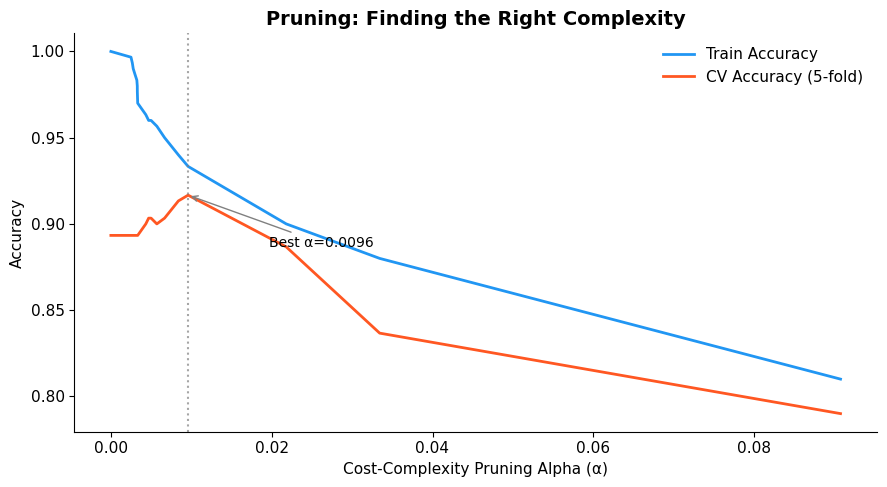

Without pruning: 1.000 train / 0.893 CV
Best pruned:     0.933 train / 0.917 CV


In [7]:
# ── Cost-complexity pruning path ──

clf_full = DecisionTreeClassifier(random_state=42)
clf_full.fit(X_moons, y_moons)
path = clf_full.cost_complexity_pruning_path(X_moons, y_moons)
alphas = path.ccp_alphas[:-1]  # Last alpha prunes to root

# Train a tree at each alpha, evaluate with cross-validation
train_scores, cv_scores = [], []
for alpha in alphas:
    clf_pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf_pruned.fit(X_moons, y_moons)
    train_scores.append(clf_pruned.score(X_moons, y_moons))
    cv_scores.append(cross_val_score(clf_pruned, X_moons, y_moons, cv=5).mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(alphas, train_scores, color=COLORS[0], lw=2, label='Train Accuracy')
ax.plot(alphas, cv_scores, color=COLORS[1], lw=2, label='CV Accuracy (5-fold)')
best_alpha = alphas[np.argmax(cv_scores)]
ax.axvline(best_alpha, color='gray', ls=':', alpha=0.7)
ax.annotate(f'Best α={best_alpha:.4f}', xy=(best_alpha, max(cv_scores)),
            xytext=(best_alpha + 0.01, max(cv_scores) - 0.03),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax.set_xlabel('Cost-Complexity Pruning Alpha (α)')
ax.set_ylabel('Accuracy')
ax.set_title('Pruning: Finding the Right Complexity')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f'Without pruning: {train_scores[0]:.3f} train / {cv_scores[0]:.3f} CV')
print(f'Best pruned:     {train_scores[np.argmax(cv_scores)]:.3f} train / {max(cv_scores):.3f} CV')

## 1.6 Decision Tree Summary

**✅ Strengths:**
- Interpretable (white-box model)
- Handles mixed feature types, no scaling needed
- Feature importance built-in
- Fast training and prediction

**❌ Weaknesses:**
- High variance (unstable — small data changes → different tree)
- Axis-aligned splits only (can't capture diagonal boundaries easily)
- Prone to overfitting without pruning
- Greedy algorithm — no guarantee of global optimum

---

💡 **The high variance problem is exactly what motivates ensembles.**

---

---
# Part 2: Ensemble Methods — The Big Picture
---

## The Bias-Variance Decomposition

For any model, the expected error decomposes as:

$$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

| Strategy | How it reduces error | Base learner |
|---|---|---|
| **Bagging** (Random Forest) | Reduces **variance** by averaging | Deep trees (low bias, high variance) |
| **Boosting** (AdaBoost, GBM) | Reduces **bias** by sequential correction | Shallow trees (high bias, low variance) |

This is the single most important conceptual distinction for interviews.

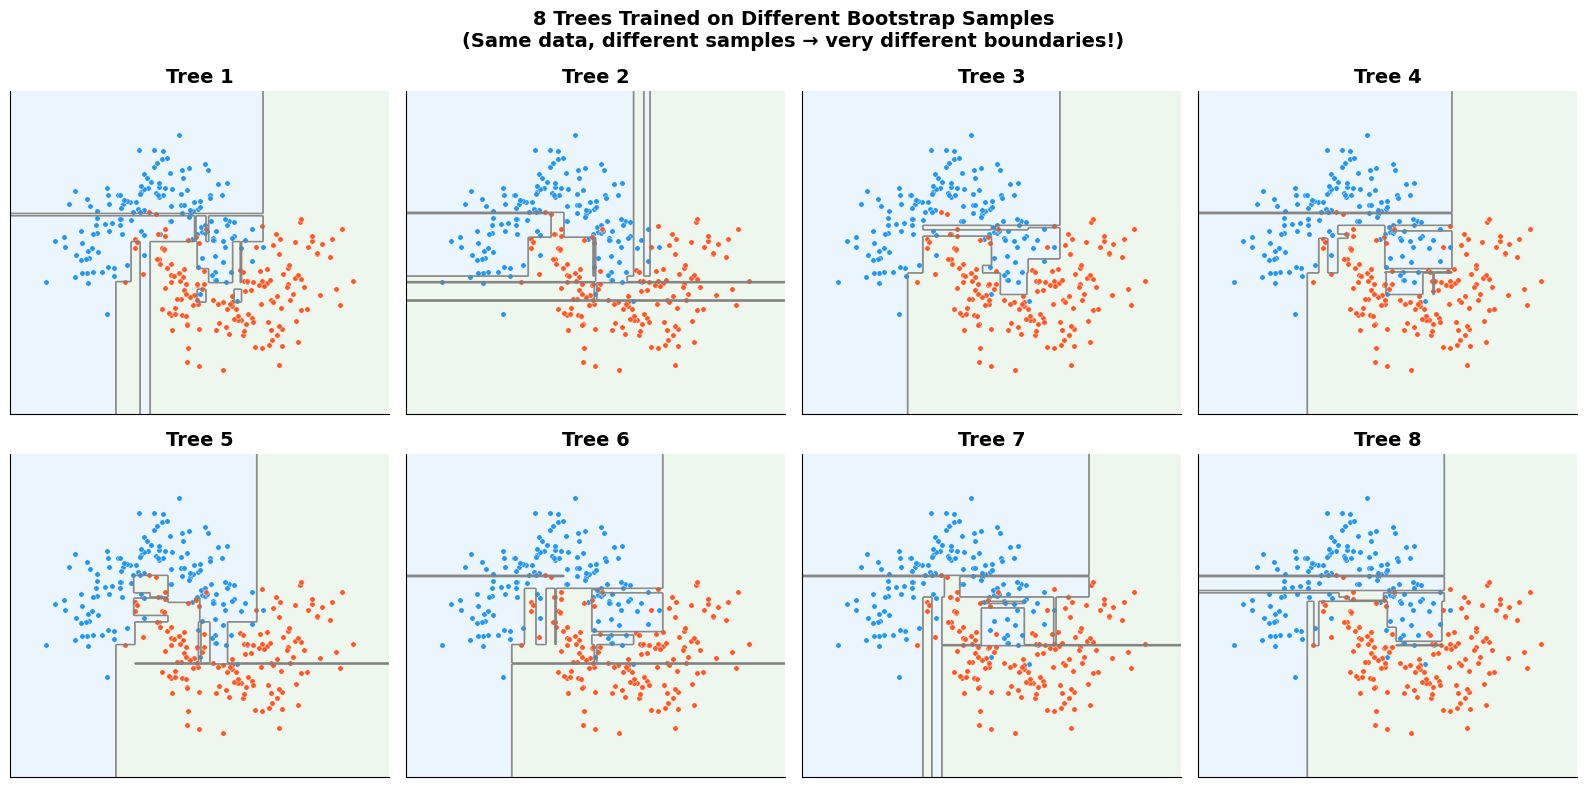

Each tree sees a slightly different dataset → produces a different model.
This is HIGH VARIANCE. Averaging them stabilizes the prediction.


In [8]:
# ── Demonstrate high variance of single trees ──
# Train multiple trees on bootstrap samples → they all look different

np.random.seed(42)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    # Bootstrap sample
    idx = np.random.choice(len(X_moons), size=len(X_moons), replace=True)
    X_boot, y_boot = X_moons[idx], y_moons[idx]
    
    clf = DecisionTreeClassifier(random_state=i)
    clf.fit(X_boot, y_boot)
    plot_decision_boundary(ax, clf, X_moons, y_moons, f'Tree {i+1}')

fig.suptitle('8 Trees Trained on Different Bootstrap Samples\n(Same data, different samples → very different boundaries!)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Each tree sees a slightly different dataset → produces a different model.')
print('This is HIGH VARIANCE. Averaging them stabilizes the prediction.')

---
# Part 3: Random Forest (Bagging + Feature Randomness)
---

## 3.1 The Algorithm

1. Draw $B$ **bootstrap samples** (sample with replacement) from the training set
2. For each sample, grow a deep decision tree, but at each split:
   - Consider only a **random subset of $m$ features** (not all $p$)
   - Pick the best split among those $m$ features
3. Aggregate predictions:
   - **Classification:** majority vote across all $B$ trees
   - **Regression:** average prediction across all $B$ trees

### Why feature randomness?

Without it, if one feature is very strong, most bootstrap trees will split on it first → trees become **correlated** → averaging doesn't reduce variance much.

The variance of the average of $B$ correlated variables with correlation $\rho$ and variance $\sigma^2$:

$$\text{Var}\left(\frac{1}{B}\sum X_i\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Feature randomness **reduces $\rho$** (decorrelates trees), which reduces the first term.

### Default $m$ values
- Classification: $m = \sqrt{p}$
- Regression: $m = p/3$

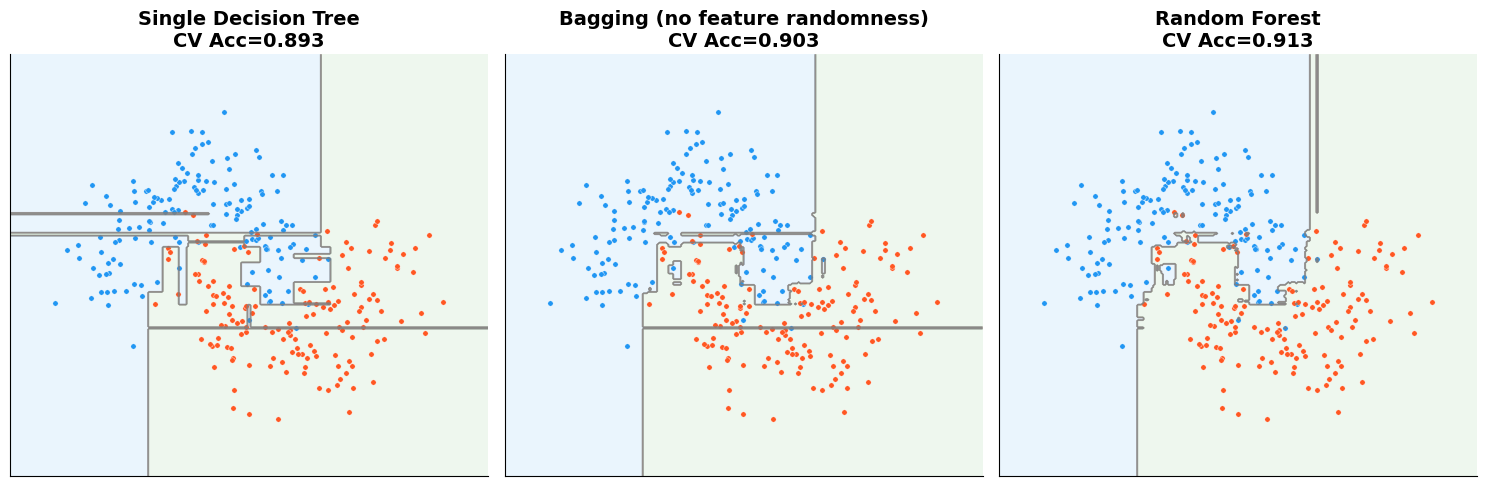

Notice how the ensemble boundaries are much smoother!
Random Forest has slightly smoother boundaries than plain Bagging
because the feature randomness further decorrelates the trees.


In [9]:
# ── Random Forest vs Single Tree vs Bagging ──

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [
    ('Single Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Bagging (no feature randomness)',
     BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                       max_features=1.0, random_state=42)),
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, random_state=42)),
]

for ax, (name, clf) in zip(axes, models):
    clf.fit(X_moons, y_moons)
    cv = cross_val_score(clf, X_moons, y_moons, cv=5).mean()
    plot_decision_boundary(ax, clf, X_moons, y_moons, f'{name}\nCV Acc={cv:.3f}')

plt.tight_layout()
plt.show()

print('Notice how the ensemble boundaries are much smoother!')
print('Random Forest has slightly smoother boundaries than plain Bagging\n'
      'because the feature randomness further decorrelates the trees.')

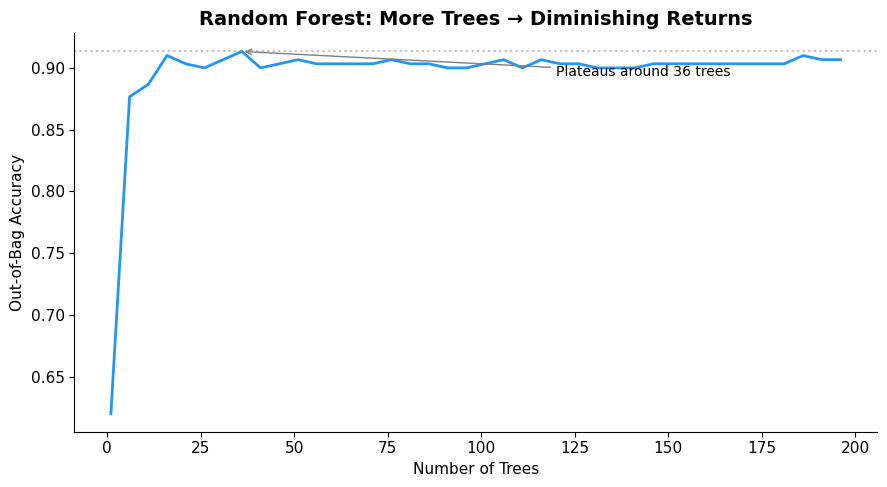

💡 Key: Random Forests do NOT overfit with more trees!
   Adding more trees always helps (or is neutral). It only costs compute.
   This is a classic interview question.


In [10]:
# ── How many trees do we need? ──

n_tree_range = list(range(1, 201, 5))
oob_scores = []

for n in n_tree_range:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf.fit(X_moons, y_moons)
    oob_scores.append(rf.oob_score_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_tree_range, oob_scores, color=COLORS[0], lw=2)
ax.axhline(max(oob_scores), color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Out-of-Bag Accuracy')
ax.set_title('Random Forest: More Trees → Diminishing Returns')
ax.annotate(f'Plateaus around {n_tree_range[np.argmax(oob_scores)]} trees',
            xy=(n_tree_range[np.argmax(oob_scores)], max(oob_scores)),
            xytext=(120, max(oob_scores) - 0.02),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
plt.tight_layout()
plt.show()

print('💡 Key: Random Forests do NOT overfit with more trees!')
print('   Adding more trees always helps (or is neutral). It only costs compute.')
print('   This is a classic interview question.')

## 3.2 Out-of-Bag (OOB) Error

Each bootstrap sample leaves out ~37% of data points (the out-of-bag samples).  
Why 37%? Each point has probability $(1 - 1/n)^n \approx 1/e \approx 0.368$ of being left out.

For each sample, we predict using **only the trees that didn't train on it** → free validation set!

**Interview tip:** OOB error is an unbiased estimate of generalization error. No need for a separate validation set.

## 3.3 Feature Importance

### Method 1: Mean Decrease in Impurity (MDI)

MDI tracks how much each feature contributes to purifying nodes across the entire forest. Every time a node splits on feature $j$, there's a Gini gain:

$$\Delta G = \frac{n_{\text{node}}}{n_{\text{total}}} \left[ \text{Gini}_{\text{parent}} - \frac{n_L}{n_{\text{node}}} \text{Gini}_L - \frac{n_R}{n_{\text{node}}} \text{Gini}_R \right]$$

For each feature, you sum up all these $\Delta G$ values from every node that splits on that feature, across every tree, then average over all trees. Finally, normalize so all importances sum to 1.

**⚠️ The bias problem:** A feature with 1000 unique values gets many more chances to be picked for a split than a feature with 2 unique values — simply because it offers more candidate thresholds. So MDI inflates importance for high-cardinality features even if they aren't truly predictive. A random ID column could score high.

### Method 2: Permutation Importance

Permutation importance takes a completely different approach — it measures how much the model's performance *breaks* when you destroy a feature's information:

1. Train the model and record baseline accuracy on a validation set
2. For feature $j$: randomly shuffle its values across all samples (breaking the relationship with the target while keeping the distribution intact)
3. Re-score the model on this corrupted data
4. The importance is the drop: $\text{Imp}_j = \text{Acc}_{\text{baseline}} - \text{Acc}_{\text{shuffled}}$
5. Repeat multiple times and average (to reduce randomness)

If shuffling feature $j$ tanks accuracy, that feature was important. If accuracy barely changes, the model didn't rely on it.

### Why Permutation is More Reliable

It doesn't care about how many unique values a feature has, or how often it appears in splits. It directly measures predictive contribution on held-out data.

### Tradeoff

- **MDI** — Free (computed during training), but biased toward high-cardinality features
- **Permutation** — Requires re-evaluating the model once per feature per repeat, but gives honest results

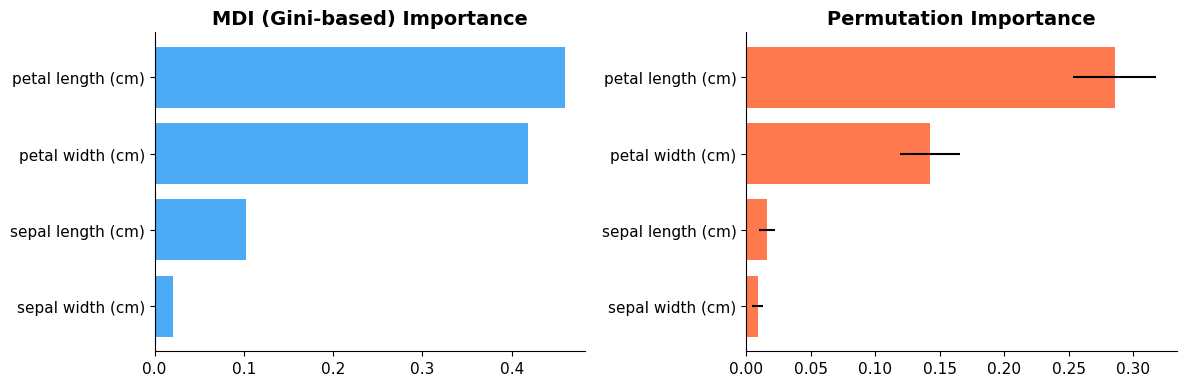

Both methods agree: petal features are most important for Iris classification.


In [20]:
# ── Feature importance comparison ──

from sklearn.inspection import permutation_importance

# Use Iris with all 4 features
rf_iris = RandomForestClassifier(n_estimators=200, random_state=42)
rf_iris.fit(iris.data, iris.target)

# MDI importance
mdi_imp = rf_iris.feature_importances_

# Permutation importance
perm_imp = permutation_importance(rf_iris, iris.data, iris.target,
                                   n_repeats=30, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sorted_idx = np.argsort(mdi_imp)
axes[0].barh(range(4), mdi_imp[sorted_idx], color=COLORS[0], alpha=0.8)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(np.array(iris.feature_names)[sorted_idx])
axes[0].set_title('MDI (Gini-based) Importance')

sorted_idx2 = np.argsort(perm_imp.importances_mean)
axes[1].barh(range(4), perm_imp.importances_mean[sorted_idx2], color=COLORS[1], alpha=0.8,
             xerr=perm_imp.importances_std[sorted_idx2])
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(np.array(iris.feature_names)[sorted_idx2])
axes[1].set_title('Permutation Importance')

plt.tight_layout()
plt.show()

print('Both methods agree: petal features are most important for Iris classification.')

---
# Part 4: Boosting
---

## 4.1 AdaBoost (Adaptive Boosting)

### The Idea
Train weak learners **sequentially**. Each new learner focuses on the mistakes of the previous ones by **re-weighting** the training samples.

### The Algorithm

1. Initialize sample weights: $w_i = 1/n$ for all samples
2. For $t = 1, 2, ..., T$:
   - Train a weak learner $h_t$ on weighted data
   - Compute weighted error: $\epsilon_t = \sum_{i: h_t(x_i) \neq y_i} w_i$
   - Compute learner weight: $\alpha_t = \frac{1}{2} \ln \frac{1 - \epsilon_t}{\epsilon_t}$
   - Update sample weights: $w_i \leftarrow w_i \cdot \exp(-\alpha_t \cdot y_i \cdot h_t(x_i))$
   - Normalize weights to sum to 1
3. Final prediction: $H(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t \cdot h_t(x)\right)$

**Key insight:** $\alpha_t$ is higher for more accurate learners. Misclassified samples get higher weights.

In [21]:
# ── AdaBoost from scratch ──

class SimpleAdaBoost:
    """AdaBoost implemented from scratch for educational purposes."""
    
    def __init__(self, n_estimators=10):
        self.n_estimators = n_estimators
        self.stumps = []       # Weak learners (decision stumps)
        self.alphas = []       # Learner weights
        self.weight_history = []  # For visualization
    
    def fit(self, X, y):
        n = len(y)
        y_coded = np.where(y == 0, -1, 1)  # AdaBoost uses {-1, +1}
        w = np.ones(n) / n                  # Initialize equal weights
        
        for t in range(self.n_estimators):
            self.weight_history.append(w.copy())
            
            # Train a decision stump (depth-1 tree)
            stump = DecisionTreeClassifier(max_depth=1)
            stump.fit(X, y, sample_weight=w)
            
            pred = stump.predict(X)
            pred_coded = np.where(pred == 0, -1, 1)
            
            # Weighted error
            miss = pred != y
            epsilon = np.sum(w[miss])
            epsilon = np.clip(epsilon, 1e-10, 1 - 1e-10)
            
            # Learner weight
            alpha = 0.5 * np.log((1 - epsilon) / epsilon)
            
            # Update sample weights
            w = w * np.exp(-alpha * y_coded * pred_coded)
            w = w / w.sum()  # Normalize
            
            self.stumps.append(stump)
            self.alphas.append(alpha)
        
        return self
    
    def predict(self, X):
        # Weighted vote
        total = np.zeros(len(X))
        for alpha, stump in zip(self.alphas, self.stumps):
            pred = np.where(stump.predict(X) == 0, -1, 1)
            total += alpha * pred
        return (np.sign(total) + 1) // 2  # Back to {0, 1}

# Train and visualize
ada = SimpleAdaBoost(n_estimators=10).fit(X_moons, y_moons)
print('Learner weights (alpha):', [f'{a:.3f}' for a in ada.alphas])
print(f'Final accuracy: {accuracy_score(y_moons, ada.predict(X_moons)):.3f}')

Learner weights (alpha): ['0.725', '0.585', '0.560', '0.573', '0.342', '0.298', '0.276', '0.370', '0.111', '0.323']
Final accuracy: 0.933


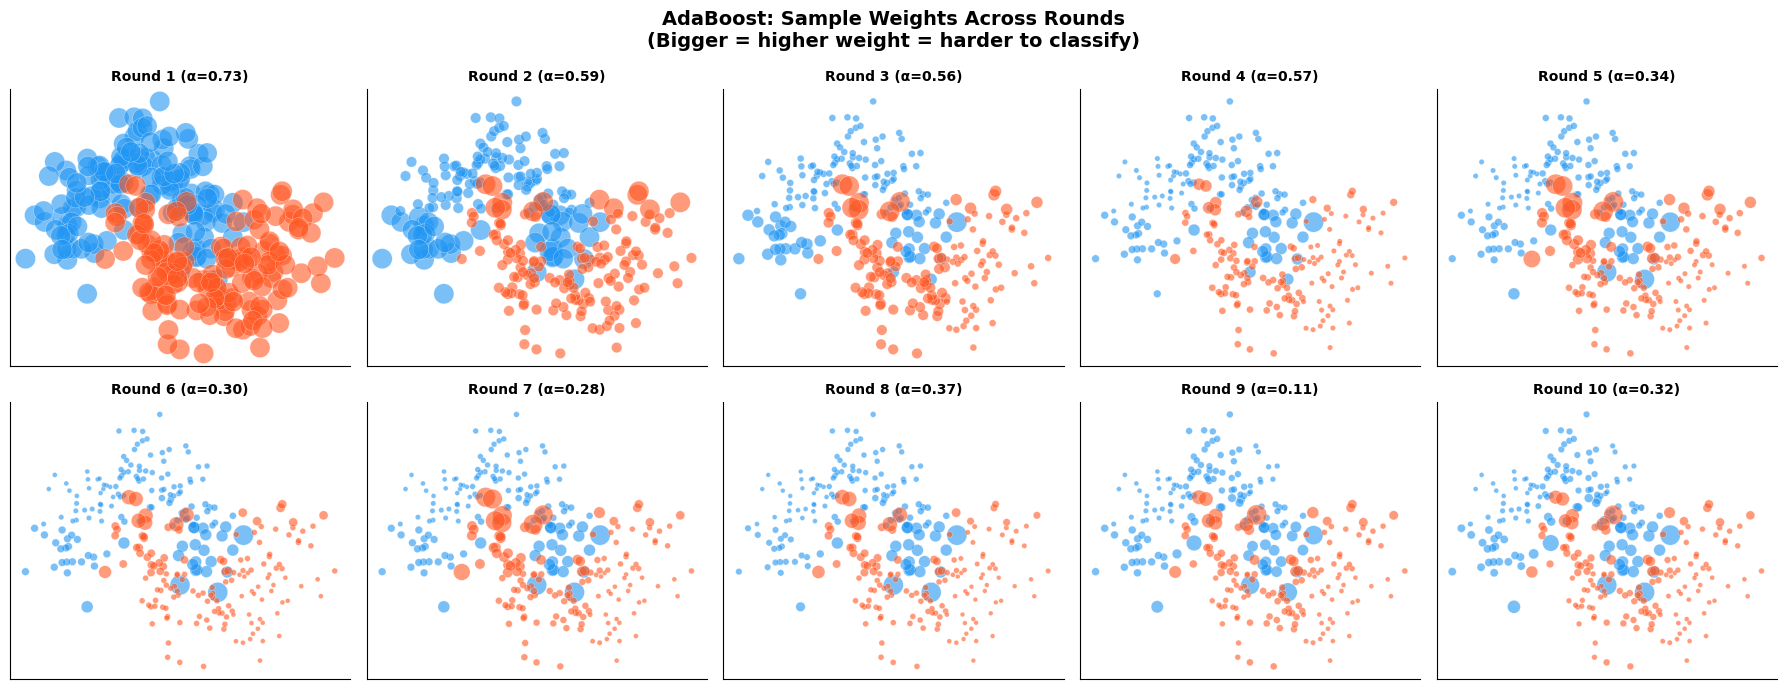

Notice: Points near the decision boundary get larger weights over time!
The algorithm focuses on the hard-to-classify samples.


In [22]:

# ── Visualize how AdaBoost re-weights samples ──

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, ax in enumerate(axes.flat):
    weights = ada.weight_history[i]
    sizes = weights / weights.max() * 200 + 10  # Scale for visibility
    
    for label, color in zip([0, 1], COLORS[:2]):
        mask = y_moons == label
        ax.scatter(X_moons[mask, 0], X_moons[mask, 1], s=sizes[mask],
                  c=color, alpha=0.6, edgecolors='white', linewidths=0.3)
    
    ax.set_title(f'Round {i+1} (α={ada.alphas[i]:.2f})', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('AdaBoost: Sample Weights Across Rounds\n(Bigger = higher weight = harder to classify)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice: Points near the decision boundary get larger weights over time!')
print('The algorithm focuses on the hard-to-classify samples.')

## 4.2 Gradient Boosting

### The Idea
Instead of re-weighting samples, each new tree fits the **residual errors** (negative gradient of the loss function) of the current ensemble.

### The Algorithm (Regression, MSE loss)

1. Initialize with constant: $F_0(x) = \bar{y}$ (mean of targets)
2. For $t = 1, 2, ..., T$:
   - Compute **pseudo-residuals**: $r_i^{(t)} = y_i - F_{t-1}(x_i)$
   - Fit a regression tree $h_t$ to the residuals $r^{(t)}$
   - Update: $F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$

where $\eta$ is the **learning rate** (shrinkage parameter).

### Why "Gradient"?

For MSE loss $L = \frac{1}{2}(y - F(x))^2$, the negative gradient w.r.t. $F(x)$ is:

$$-\frac{\partial L}{\partial F(x)} = y - F(x) = \text{residual}$$

For other losses (log loss, Huber loss), the negative gradient gives different "pseudo-residuals".  
This is what makes gradient boosting so general — it works with any differentiable loss function.

In [23]:
# ── Gradient Boosting from scratch (regression) ──

# Generate a noisy regression problem
np.random.seed(42)
X_reg = np.sort(np.random.uniform(0, 10, 100)).reshape(-1, 1)
y_reg = np.sin(X_reg.ravel()) + np.random.normal(0, 0.3, 100)

class SimpleGradientBoosting:
    """Gradient Boosting for regression (MSE loss), built from scratch."""
    
    def __init__(self, n_estimators=10, learning_rate=0.3, max_depth=3):
        self.n_estimators = n_estimators
        self.lr = learning_rate
        self.max_depth = max_depth
        self.trees = []
        self.initial_pred = None
        self.residual_history = []
    
    def fit(self, X, y):
        # Step 1: Initialize with mean
        self.initial_pred = y.mean()
        current_pred = np.full(len(y), self.initial_pred)
        
        for t in range(self.n_estimators):
            # Step 2: Compute residuals (negative gradient for MSE)
            residuals = y - current_pred
            self.residual_history.append(residuals.copy())
            
            # Step 3: Fit a tree to residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)
            
            # Step 4: Update predictions
            current_pred += self.lr * tree.predict(X)
            self.trees.append(tree)
        
        return self
    
    def predict(self, X):
        pred = np.full(len(X), self.initial_pred)
        for tree in self.trees:
            pred += self.lr * tree.predict(X)
        return pred

gb = SimpleGradientBoosting(n_estimators=20, learning_rate=0.3, max_depth=2)
gb.fit(X_reg, y_reg)

print(f'Final MSE: {np.mean((y_reg - gb.predict(X_reg))**2):.4f}')

Final MSE: 0.0438


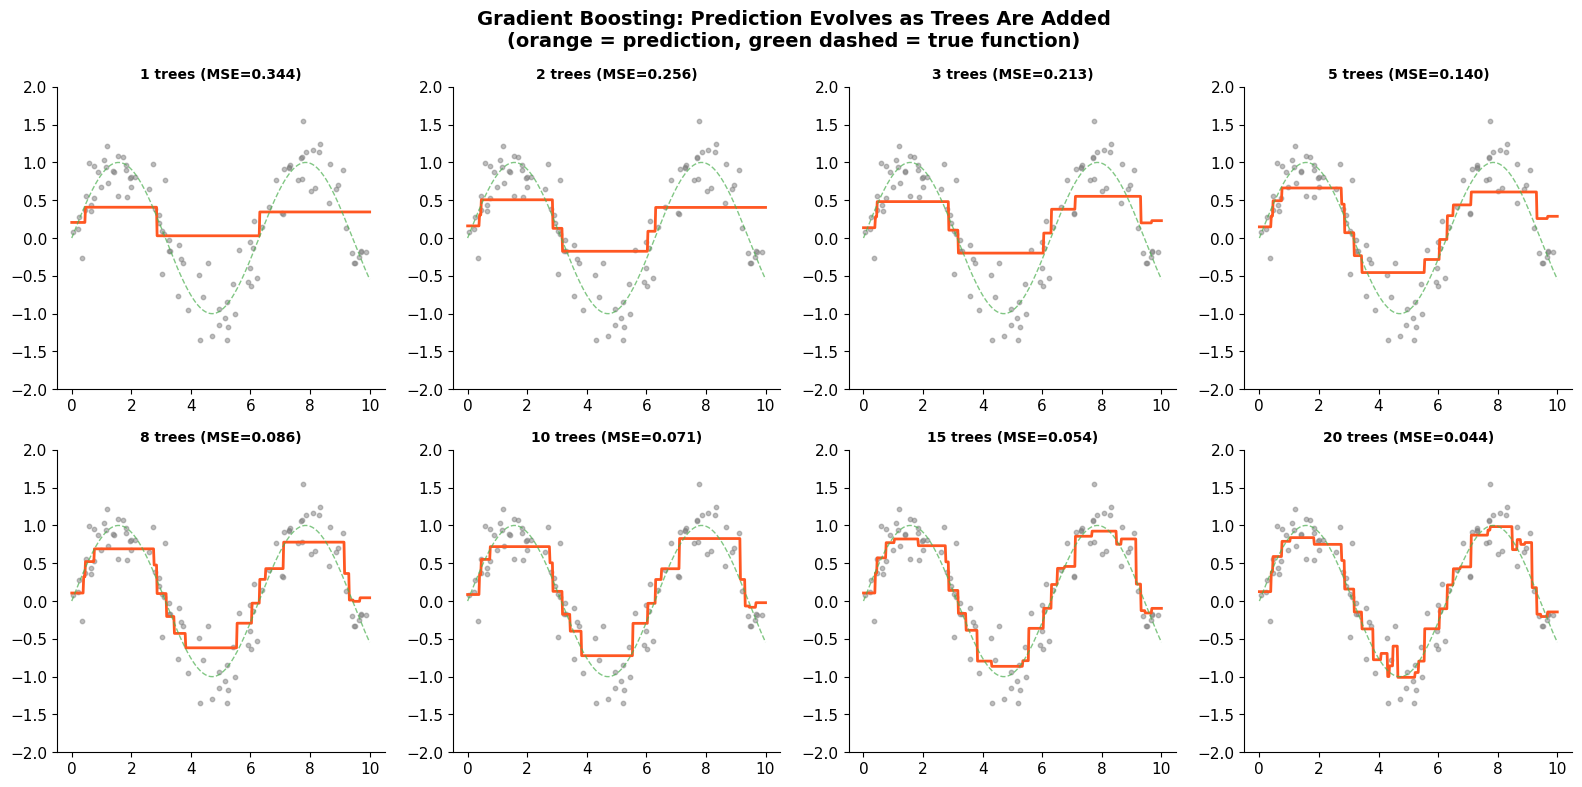

Each tree corrects the residuals of the previous ensemble.
The prediction gradually converges to the true function.


In [24]:
# ── Visualize Gradient Boosting building up the prediction ──

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
X_plot = np.linspace(0, 10, 500).reshape(-1, 1)
stages = [1, 2, 3, 5, 8, 10, 15, 20]

for ax, n_trees in zip(axes.flat, stages):
    # Predict using only first n_trees
    pred = np.full(len(X_plot), gb.initial_pred)
    for tree in gb.trees[:n_trees]:
        pred += gb.lr * tree.predict(X_plot)
    
    ax.scatter(X_reg, y_reg, c='gray', s=10, alpha=0.5)
    ax.plot(X_plot, pred, color=COLORS[1], lw=2)
    ax.plot(X_plot, np.sin(X_plot), color=COLORS[2], lw=1, ls='--', alpha=0.7)
    mse = np.mean((y_reg - gb.predict(X_reg) if n_trees == 20 else 
                   y_reg - (np.full(len(X_reg), gb.initial_pred) + 
                            sum(gb.lr * t.predict(X_reg) for t in gb.trees[:n_trees])))**2)
    ax.set_title(f'{n_trees} trees (MSE={mse:.3f})', fontsize=10)
    ax.set_ylim(-2, 2)

fig.suptitle('Gradient Boosting: Prediction Evolves as Trees Are Added\n'
             '(orange = prediction, green dashed = true function)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Each tree corrects the residuals of the previous ensemble.')
print('The prediction gradually converges to the true function.')

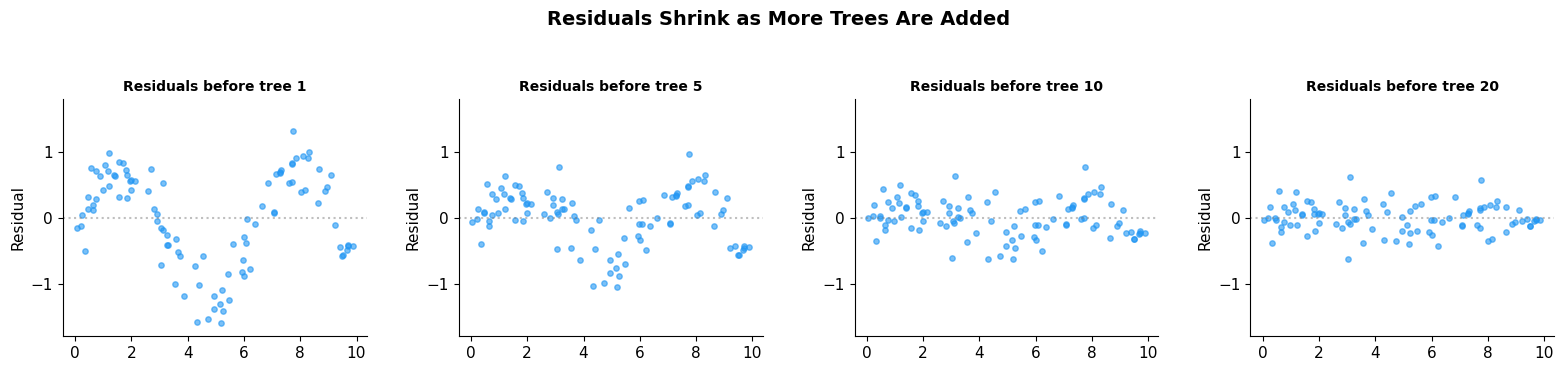

In [16]:
# ── Visualize the residuals shrinking ──

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
residual_stages = [0, 4, 9, 19]

for ax, idx in zip(axes, residual_stages):
    ax.scatter(X_reg, gb.residual_history[idx], c=COLORS[0], s=15, alpha=0.6)
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    ax.set_title(f'Residuals before tree {idx+1}', fontsize=10)
    ax.set_ylim(-1.8, 1.8)
    ax.set_ylabel('Residual')

fig.suptitle('Residuals Shrink as More Trees Are Added', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 4.3 Learning Rate (Shrinkage) — The Key Hyperparameter

$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$

- **Small $\eta$** (e.g., 0.01–0.1): Slower learning, needs more trees, but **generalizes better**
- **Large $\eta$** (e.g., 0.5–1.0): Faster learning, fewer trees needed, but **overfits faster**

**Rule of thumb:** Use a small learning rate with many trees. The optimal (learning_rate, n_estimators) pair is found via early stopping.

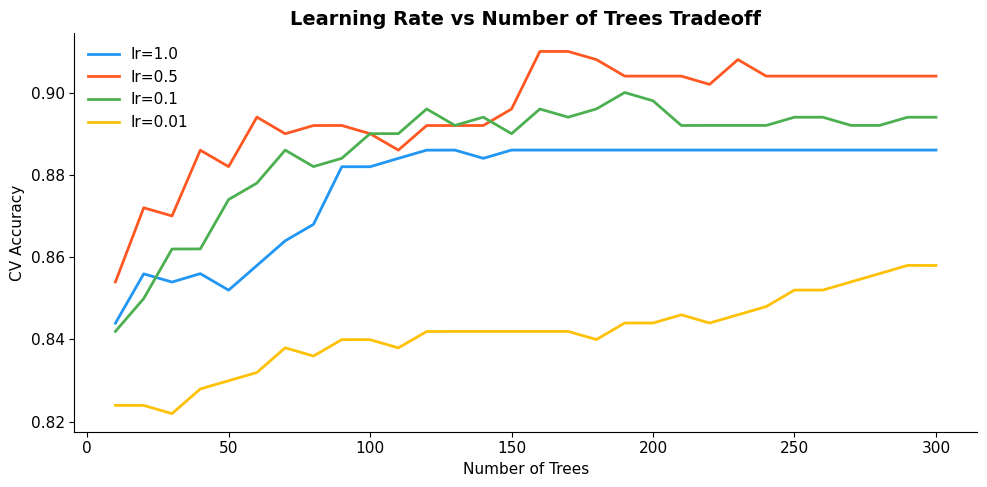

Small learning rate + many trees = best generalization.
Large learning rate = fast overfitting, then performance degrades.


In [17]:
# ── Learning rate effect ──

X_clf, y_clf = make_classification(n_samples=500, n_features=20,
                                    n_informative=10, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))

for lr, color in zip([1.0, 0.5, 0.1, 0.01], COLORS):
    train_scores = []
    cv_scores = []
    n_range = range(10, 301, 10)
    
    for n in n_range:
        gb_clf = GradientBoostingClassifier(
            n_estimators=n, learning_rate=lr, max_depth=3, random_state=42
        )
        cv = cross_val_score(gb_clf, X_clf, y_clf, cv=3, scoring='accuracy').mean()
        cv_scores.append(cv)
    
    ax.plot(n_range, cv_scores, color=color, lw=2, label=f'lr={lr}')

ax.set_xlabel('Number of Trees')
ax.set_ylabel('CV Accuracy')
ax.set_title('Learning Rate vs Number of Trees Tradeoff')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('Small learning rate + many trees = best generalization.')
print('Large learning rate = fast overfitting, then performance degrades.')

## 4.4 XGBoost Enhancements

XGBoost adds several improvements over vanilla gradient boosting:

**1. Regularized Objective:**

$$\text{Obj} = \sum_{i=1}^{n} L(y_i, \hat{y}_i) + \sum_{t=1}^{T} \Omega(f_t)$$

where $\Omega(f_t) = \gamma |T| + \frac{1}{2}\lambda \sum_{j=1}^{|T|} w_j^2$

- $\gamma$ penalizes the number of leaves (encourages simpler trees)
- $\lambda$ penalizes large leaf weights (L2 regularization)

**2. Second-Order Approximation:**

Uses both gradient $g_i$ and Hessian $h_i$ of the loss:

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda}\right] - \gamma$$

where $G = \sum g_i$ and $H = \sum h_i$ for each child.

**3. Other Tricks:**
- Column subsampling (like Random Forest)
- Histogram-based splits (faster)
- Built-in handling of missing values
- Parallel tree construction

---
# Part 5: Comparing All Methods
---

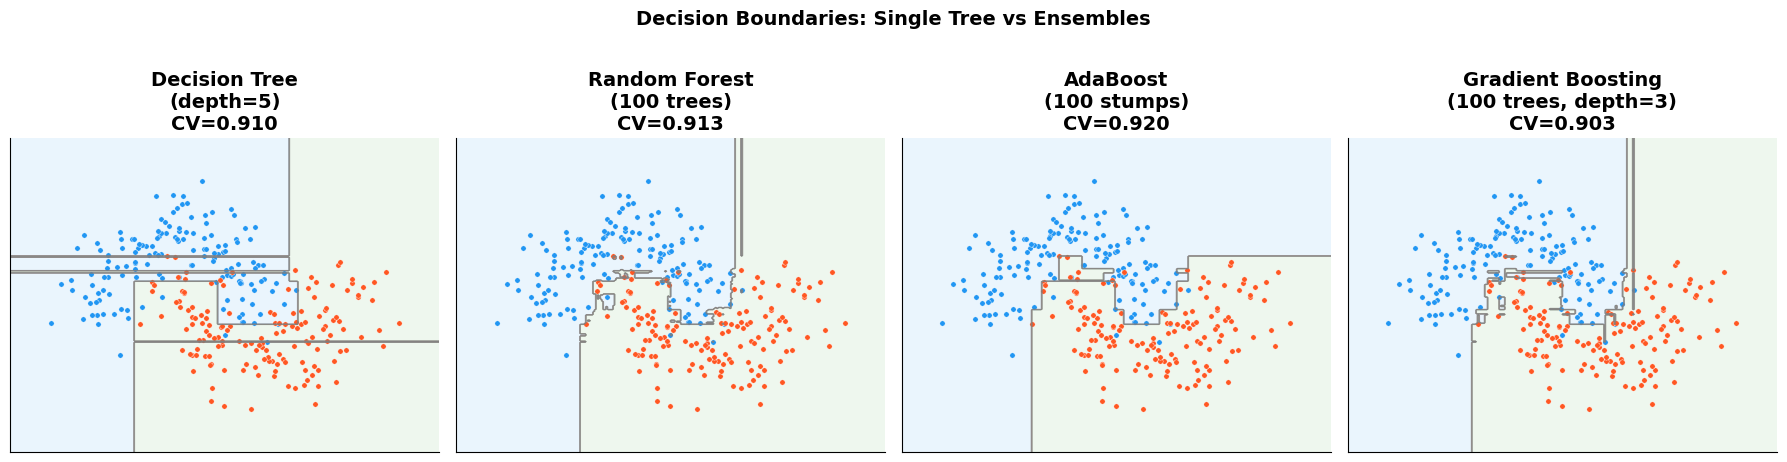

In [18]:
# ── Side-by-side decision boundaries ──

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

classifiers = [
    ('Decision Tree\n(depth=5)', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Random Forest\n(100 trees)', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('AdaBoost\n(100 stumps)', AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting\n(100 trees, depth=3)', GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
]

for ax, (name, clf) in zip(axes, classifiers):
    clf.fit(X_moons, y_moons)
    cv = cross_val_score(clf, X_moons, y_moons, cv=5).mean()
    plot_decision_boundary(ax, clf, X_moons, y_moons, f'{name}\nCV={cv:.3f}')

plt.suptitle('Decision Boundaries: Single Tree vs Ensembles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

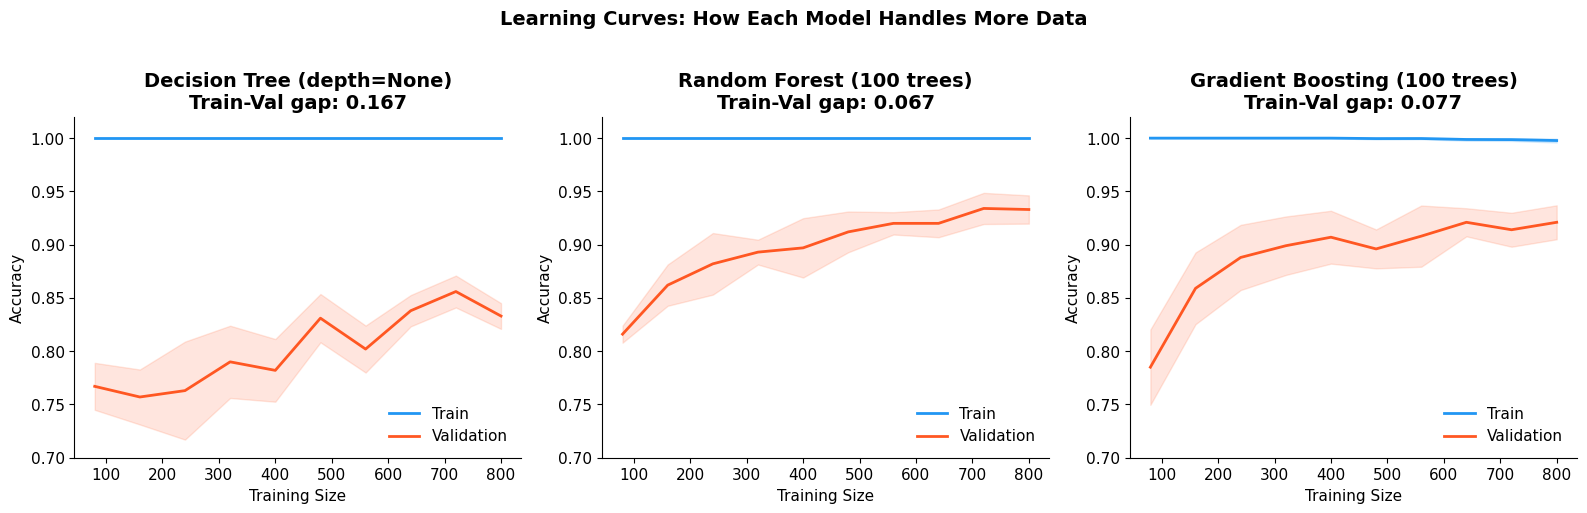

Decision Tree: Large gap (high variance) — overfits training data.
Random Forest: Small gap — bagging reduces variance effectively.
Gradient Boosting: Smallest gap — learns efficiently with low bias + controlled variance.


In [19]:
# ── Learning curves: Bias vs Variance in action ──

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_lc = [
    ('Decision Tree (depth=None)', DecisionTreeClassifier(random_state=42)),
    ('Random Forest (100 trees)', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting (100 trees)', GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
]

X_lc, y_lc = make_classification(n_samples=1000, n_features=20,
                                  n_informative=10, random_state=42)

for ax, (name, model) in zip(axes, models_lc):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_lc, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', n_jobs=-1
    )
    
    ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color=COLORS[0])
    ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color=COLORS[1])
    ax.plot(train_sizes, train_scores.mean(axis=1), color=COLORS[0], lw=2, label='Train')
    ax.plot(train_sizes, val_scores.mean(axis=1), color=COLORS[1], lw=2, label='Validation')
    
    gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
    ax.set_title(f'{name}\nTrain-Val gap: {gap:.3f}')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('Accuracy')
    ax.legend(frameon=False, loc='lower right')
    ax.set_ylim(0.7, 1.02)

plt.suptitle('Learning Curves: How Each Model Handles More Data',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Decision Tree: Large gap (high variance) — overfits training data.')
print('Random Forest: Small gap — bagging reduces variance effectively.')
print('Gradient Boosting: Smallest gap — learns efficiently with low bias + controlled variance.')

---
# Part 6: When to Use Which?
---

## Quick Decision Guide

| Scenario | Best Choice | Why |
|---|---|---|
| Need interpretability | **Decision Tree** | White-box, easy to explain |
| Quick baseline, no tuning | **Random Forest** | Works well out-of-box, few hyperparameters |
| Maximum predictive accuracy | **Gradient Boosting / XGBoost** | Usually wins competitions |
| Small dataset | **Boosting** | Lower bias helps |
| Very large dataset | **Random Forest** | Parallelizable, less prone to overfit |
| Noisy data / outliers | **Random Forest** | More robust (averaging vs sequential) |
| Imbalanced classes | **Boosting** | Naturally focuses on hard examples |
| Fast training needed | **Random Forest** | Fully parallelizable |
| Feature importance needed | **Both work** | Use permutation importance for reliability |

## Common Interview Questions & Answers

**Q: Can Random Forest overfit?**  
A: More trees ≠ more overfitting (the variance keeps decreasing or stays flat). But individual trees can be too deep → increase `min_samples_leaf`.

**Q: Can Gradient Boosting overfit?**  
A: Yes! More trees CAN overfit because each tree depends on previous ones. Use early stopping + small learning rate.

**Q: Bagging vs Boosting?**  
A: Bagging reduces variance (parallel, independent). Boosting reduces bias (sequential, dependent). Bagging is more robust; boosting achieves lower error with proper tuning.

**Q: How does XGBoost handle missing values?**  
A: It learns the optimal direction (left or right) for missing values at each split during training.

**Q: Why is Random Forest embarrassingly parallel?**  
A: Each tree is trained independently on its own bootstrap sample. No dependencies between trees.

**Q: What's the bias-variance tradeoff in tree depth?**  
A: Shallow trees = high bias, low variance. Deep trees = low bias, high variance. Bagging uses deep trees (reduces variance). Boosting uses shallow trees (reduces bias sequentially).

In [ ]:
# ── Final comparison on a realistic dataset ──

from sklearn.model_selection import cross_validate
import time

# Create a moderately complex dataset
X_final, y_final = make_classification(
    n_samples=2000, n_features=30, n_informative=15,
    n_redundant=5, n_clusters_per_class=3, random_state=42
)

models_final = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
}

results = []
for name, model in models_final.items():
    start = time.time()
    cv_result = cross_validate(model, X_final, y_final, cv=5,
                                scoring='accuracy', return_train_score=True)
    elapsed = time.time() - start
    results.append({
        'Model': name,
        'Train Acc': f"{cv_result['train_score'].mean():.4f}",
        'CV Acc': f"{cv_result['test_score'].mean():.4f}",
        'Std': f"±{cv_result['test_score'].std():.4f}",
        'Time (s)': f"{elapsed:.2f}",
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print('\nGradient Boosting typically wins on accuracy.')
print('Random Forest is faster (parallelizable) and nearly as good.')
print('Decision Tree is fast but clearly inferior — high variance.')

---
# Part 7: Key Hyperparameters Cheat Sheet
---

## Decision Tree
- `max_depth`: Start with 5–10, tune via CV
- `min_samples_leaf`: 5–20 for small datasets
- `ccp_alpha`: Use pruning path to find optimal

## Random Forest
- `n_estimators`: 100–500 (more is rarely harmful, just slower)
- `max_features`: `'sqrt'` for classification, `'auto'` (=n/3) for regression
- `min_samples_leaf`: 1–5 usually fine
- `oob_score=True`: Free validation!

## Gradient Boosting / XGBoost
- `n_estimators`: 100–1000+ (use early stopping)
- `learning_rate`: 0.01–0.1 (smaller = more trees needed)
- `max_depth`: 3–8 (shallow trees!)
- `subsample`: 0.7–0.9 (stochastic gradient boosting)
- `colsample_bytree`: 0.5–0.8 (column subsampling)
- `reg_alpha` (L1), `reg_lambda` (L2): Regularization

---

## Summary Diagram

```
                    ENSEMBLE METHODS
                    ┌─────────┴──────────┐
                 BAGGING              BOOSTING
             (reduce variance)     (reduce bias)
                  │                     │
            ┌─────┴─────┐        ┌──────┴──────┐
         Random       Bagging   AdaBoost   Gradient
         Forest      (vanilla)             Boosting
            │                                 │
     + feature                          ┌─────┴─────┐
     randomness                      XGBoost   LightGBM
     (decorrelates                 CatBoost
      trees)
```

---

**You're now equipped to:**
1. Explain how trees split (Gini/Entropy/MSE) with math
2. Implement bagging and boosting from scratch
3. Choose the right method for any scenario
4. Tune hyperparameters effectively
5. Answer any interview question on these topics with confidence